In [1]:
# ==================== 第一部分：导入库和配置 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import time
import pickle
import json
from datetime import datetime

# 机器学习模型
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression

# 统计和优化
from scipy.stats import rankdata
from scipy.optimize import differential_evolution, dual_annealing

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出目录
output_dirs = ['models', 'plots', 'csv', 'reports', 'predictions']
for dir_name in output_dirs:
    os.makedirs(f'stk_RF-SVM_test1/{dir_name}', exist_ok=True)

print("="*60)
print("环境配置完成！")
print(f"输出目录已创建: {', '.join(output_dirs)}")
print("="*60)

环境配置完成！
输出目录已创建: models, plots, csv, reports, predictions


In [2]:
# ==================== 第三部分：数据加载和预处理 ====================
def load_and_preprocess_data(file_path):
    """加载数据并进行预处理，计算缺失的未来收益率"""
    print("正在加载数据...")
    df = pd.read_csv(file_path)
    print(f"原始数据形状: {df.shape}")
    print(f"原始数据列: {df.columns.tolist()}")
    
    # 转换日期格式
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)
    
    print(f"\n原始数据中有 future_5d_return，需要计算 future_10d_return 和 future_20d_return")
    
    # 计算未来收益率
    print("\n计算未来收益率...")
    
    # 获取所有股票代码
    stock_codes = df['ts_code'].unique()
    print(f"共有 {len(stock_codes)} 只股票")
    
    # 为每个股票计算未来收益率
    all_dfs = []
    for i, stock_code in enumerate(stock_codes):
        if i % 50 == 0:
            print(f"  处理第 {i+1}/{len(stock_codes)} 只股票...")
        
        # 获取该股票的数据
        stock_df = df[df['ts_code'] == stock_code].sort_values('trade_date').reset_index(drop=True)
        
        # 获取收盘价序列
        close_prices = stock_df['close'].values
        n = len(stock_df)
        
        # 计算未来收益率
        future_5d = np.full(n, np.nan)
        future_10d = np.full(n, np.nan)
        future_20d = np.full(n, np.nan)
        
        for idx in range(n):
            # 未来5日收益率
            if idx + 5 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 5]):
                future_5d[idx] = (close_prices[idx + 5] / close_prices[idx]) - 1
            
            # 未来10日收益率
            if idx + 10 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 10]):
                future_10d[idx] = (close_prices[idx + 10] / close_prices[idx]) - 1
            
            # 未来20日收益率
            if idx + 20 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 20]):
                future_20d[idx] = (close_prices[idx + 20] / close_prices[idx]) - 1
        
        # 添加到DataFrame
        stock_df['future_5d_return'] = future_5d
        stock_df['future_10d_return'] = future_10d
        stock_df['future_20d_return'] = future_20d
        
        all_dfs.append(stock_df)
    
    # 合并所有股票数据
    df = pd.concat(all_dfs, ignore_index=True)
    print(f"计算完成，数据形状: {df.shape}")
    
    # 处理缺失值：使用向前填充和向后填充
    print("\n处理缺失值...")
    
    # 先处理未来收益率列的缺失值
    future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
    
    for col in future_cols:
        if col in df.columns:
            print(f"处理 {col} 的缺失值...")
            
            # 对每个股票分组进行填充
            for stock_code in df['ts_code'].unique():
                mask = df['ts_code'] == stock_code
                # 向前填充 - 使用ffill()
                df.loc[mask, col] = df.loc[mask, col].ffill()
                # 向后填充 - 使用bfill()
                df.loc[mask, col] = df.loc[mask, col].bfill()
            
            # 将剩余NaN填充为0
            df[col] = df[col].fillna(0)
            
            # 统计非零值
            non_zero = (df[col] != 0).sum()
            print(f"  {col}: 非零值数量 {non_zero}/{len(df)} ({non_zero/len(df)*100:.2f}%)")
        else:
            print(f"警告: {col} 不存在")
    
    # 处理其他特征列的缺失值
    print("\n处理特征列缺失值...")
    feature_cols = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'year_month'] + future_cols]
    
    for col in feature_cols:
        try:
            # 对每个股票分组进行填充
            for stock_code in df['ts_code'].unique():
                mask = df['ts_code'] == stock_code
                # 向前填充
                df.loc[mask, col] = df.loc[mask, col].ffill()
                # 向后填充
                df.loc[mask, col] = df.loc[mask, col].bfill()
            # 将剩余NaN填充为0
            df[col] = df[col].fillna(0)
        except Exception as e:
            print(f"  处理列 {col} 时出错: {e}, 使用全局填充")
            df[col] = df[col].ffill()
            df[col] = df[col].bfill()
            df[col] = df[col].fillna(0)
    
    # 删除可能包含inf的列
    df = df.replace([np.inf, -np.inf], 0)
    
    print(f"\n处理后数据形状: {df.shape}")
    print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
    print(f"股票数量: {df['ts_code'].nunique()}")
    
    # 检查最终数据
    print("\n最终数据统计:")
    print(f"总行数: {len(df)}")
    print(f"列数: {len(df.columns)}")
    print("\n未来收益率统计:")
    for col in ['future_5d_return', 'future_10d_return', 'future_20d_return']:
        if col in df.columns:
            valid_data = df[col][df[col] != 0]
            if len(valid_data) > 0:
                print(f"  {col}: 均值={valid_data.mean():.6f}, 标准差={valid_data.std():.6f}, 范围=[{valid_data.min():.6f}, {valid_data.max():.6f}]")
                print(f"    非零值: {len(valid_data)}/{len(df)} ({len(valid_data)/len(df)*100:.2f}%)")
            else:
                print(f"  {col}: 全为零")
    
    # 验证计算是否正确
    print("\n验证计算结果（前10行）:")
    print(df[['ts_code', 'trade_date', 'close', 'future_5d_return', 'future_10d_return', 'future_20d_return']].head(10))
    
    return df

# 加载并处理数据
df = load_and_preprocess_data('../extracted_data/selected_factors_with_data1.csv')
print("="*60)

正在加载数据...
原始数据形状: (23979, 36)
原始数据列: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'auto_kurtosis_20', 'hist_vol_60', 'auto_volatility_20', 'hist_vol_20', 'auto_volatility_60', 'auto_std_60_1', 'auto_amount_ma_30', 'auto_open_ratio_60', 'auto_quantile_0.75_30', 'auto_amount_ma_60', 'auto_skew_30_1', 'auto_kurtosis_20_1', 'auto_volatility_20_1', 'auto_volatility_60_1', 'auto_std_60', 'auto_amount_ma_30_1', 'auto_open_ratio_60_1', 'auto_open_log_return_60', 'auto_open_log_return_60_1', 'auto_quantile_0.75_30_1', 'future_5d_return', 'year_month']

原始数据中有 future_5d_return，需要计算 future_10d_return 和 future_20d_return

计算未来收益率...
共有 100 只股票
  处理第 1/100 只股票...
  处理第 51/100 只股票...
计算完成，数据形状: (23979, 38)

处理缺失值...
处理 future_5d_return 的缺失值...
  future_5d_return: 非零值数量 23735/23979 (98.98%)
处理 future_10d_return 的缺失值...
  future_10d_return: 非零值数量 23807/23979 (99.28%)
处理 future_20d_return

In [3]:
# ==================== 数据完整性检查 ====================
print("\n数据完整性检查:")
print("-"*60)

# 检查所有未来收益率列
future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
for col in future_cols:
    if col in df.columns:
        non_zero = (df[col] != 0).sum()
        print(f"{col}: 存在, 非零值: {non_zero}/{len(df)} ({non_zero/len(df)*100:.2f}%)")
        if non_zero > 0:
            valid_data = df[col][df[col] != 0]
            print(f"  均值: {valid_data.mean():.6f}")
            print(f"  标准差: {valid_data.std():.6f}")
            print(f"  范围: [{valid_data.min():.6f}, {valid_data.max():.6f}]")
    else:
        print(f"{col}: 不存在")

# 检查每个股票的数据量
stock_counts = df.groupby('ts_code').size()
print(f"\n每只股票样本数: 均值={stock_counts.mean():.1f}, 范围=[{stock_counts.min()}, {stock_counts.max()}]")

# 检查是否有股票数据不足
insufficient = stock_counts[stock_counts < 20]
if len(insufficient) > 0:
    print(f"警告: {len(insufficient)} 只股票数据不足20个交易日")
    print(f"这些股票示例: {insufficient.index.tolist()[:5]}")
else:
    print("所有股票数据充足（>=20个交易日）")

print("="*60)


数据完整性检查:
------------------------------------------------------------
future_5d_return: 存在, 非零值: 23735/23979 (98.98%)
  均值: 0.000792
  标准差: 0.088114
  范围: [-0.432526, 1.609489]
future_10d_return: 存在, 非零值: 23807/23979 (99.28%)
  均值: -0.000378
  标准差: 0.124310
  范围: [-0.465918, 2.264840]
future_20d_return: 存在, 非零值: 23869/23979 (99.54%)
  均值: -0.000091
  标准差: 0.180421
  范围: [-0.603509, 2.325581]

每只股票样本数: 均值=239.8, 范围=[40, 249]
所有股票数据充足（>=20个交易日）


In [4]:
# ==================== 第四部分：特征工程和标签准备 ====================
def prepare_features_and_labels(df, lookback_days=[5, 10, 20]):
    """准备特征和标签"""
    print("\n准备特征和标签...")
    
    # 定义特征列（排除非特征列）
    exclude_cols = ['ts_code', 'trade_date', 'year_month']
    
    # 添加所有未来收益率列到排除列表
    future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
    for col in future_cols:
        if col in df.columns:
            exclude_cols.append(col)
    
    # 获取特征列
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    print(f"特征数量: {len(feature_cols)}")
    print(f"特征列示例: {feature_cols[:10]}...")
    print(f"排除的列: {exclude_cols}")
    
    # 创建多个时间窗口的标签
    labels_dict = {}
    for days in lookback_days:
        col_name = f'future_{days}d_return'
        if col_name in df.columns:
            # 回归标签：未来收益率
            labels_dict[f'future_{days}d_return'] = df[col_name].values
            # 分类标签：涨跌（1表示涨，0表示跌）
            labels_dict[f'future_{days}d_class'] = (df[col_name] > 0).astype(int).values
            
            # 统计标签分布
            positive = np.sum(labels_dict[f'future_{days}d_class'] == 1)
            negative = np.sum(labels_dict[f'future_{days}d_class'] == 0)
            total = positive + negative
            if total > 0:
                print(f"  {col_name}: 上涨{positive}次, 下跌{negative}次, 比例={positive/(positive+negative):.2%}")
            else:
                print(f"  {col_name}: 所有标签为零")
        else:
            print(f"警告: {col_name} 不存在，创建占位标签")
            labels_dict[f'future_{days}d_return'] = np.zeros(len(df))
            labels_dict[f'future_{days}d_class'] = np.zeros(len(df), dtype=int)
    
    # 提取特征矩阵
    X = df[feature_cols].values
    dates = df['trade_date'].values
    codes = df['ts_code'].values
    
    print(f"\n特征矩阵形状: {X.shape}")
    print(f"日期范围: {dates.min()} 到 {dates.max()}")
    print("标签准备完成！")
    
    return X, labels_dict, dates, codes, feature_cols

X, labels_dict, dates, codes, feature_cols = prepare_features_and_labels(df)
print("="*60)


准备特征和标签...
特征数量: 32
特征列示例: ['open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg', 'daily_return', 'turnover_rate']...
排除的列: ['ts_code', 'trade_date', 'year_month', 'future_5d_return', 'future_10d_return', 'future_20d_return']
  future_5d_return: 上涨10695次, 下跌13284次, 比例=44.60%
  future_10d_return: 上涨10508次, 下跌13471次, 比例=43.82%
  future_20d_return: 上涨10576次, 下跌13403次, 比例=44.11%

特征矩阵形状: (23979, 32)
日期范围: 2024-01-02T00:00:00.000000 到 2025-01-10T00:00:00.000000
标签准备完成！


In [5]:
# ==================== 第五部分：创建滚动窗口 ====================
def create_rolling_windows_short_term(dates, train_months=3, test_months=1, step_days=20):
    """为短期数据创建滚动窗口"""
    print(f"\n创建短期滚动窗口 (训练{train_months}个月, 测试{test_months}个月)...")
    
    # 确保dates是datetime类型
    if isinstance(dates[0], np.datetime64):
        dates_dt = pd.to_datetime(dates)
    else:
        dates_dt = pd.to_datetime(dates)
    
    unique_dates = sorted(np.unique(dates_dt))
    train_days = train_months * 21
    test_days = test_months * 21
    
    print(f"训练天数: {train_days} (约{train_months}个月)")
    print(f"测试天数: {test_days} (约{test_months}个月)")
    print(f"滑动步长: {step_days}天")
    print(f"总交易日数: {len(unique_dates)}")
    
    windows = []
    
    for i in range(0, len(unique_dates) - train_days - test_days, step_days):
        train_start_idx = i
        train_end_idx = i + train_days
        test_end_idx = i + train_days + test_days
        
        if test_end_idx >= len(unique_dates):
            break
        
        train_start = unique_dates[train_start_idx]
        train_end = unique_dates[train_end_idx]
        test_start = unique_dates[train_end_idx]
        test_end = unique_dates[test_end_idx]
        
        train_indices = np.where((dates_dt >= train_start) & (dates_dt < train_end))[0]
        test_indices = np.where((dates_dt >= test_start) & (dates_dt < test_end))[0]
        
        if len(train_indices) >= 50 and len(test_indices) >= 10:
            windows.append({
                'train_start': train_start,
                'train_end': train_end,
                'test_start': test_start,
                'test_end': test_end,
                'train_indices': train_indices,
                'test_indices': test_indices,
                'n_train': len(train_indices),
                'n_test': len(test_indices)
            })
            print(f"  窗口 {len(windows)}: 训练 {len(train_indices)} 样本, 测试 {len(test_indices)} 样本")
            print(f"    训练期: {pd.to_datetime(train_start).strftime('%Y-%m-%d')} 到 {pd.to_datetime(train_end).strftime('%Y-%m-%d')}")
            print(f"    测试期: {pd.to_datetime(test_start).strftime('%Y-%m-%d')} 到 {pd.to_datetime(test_end).strftime('%Y-%m-%d')}")
    
    print(f"\n共创建 {len(windows)} 个滚动窗口")
    return windows

# 创建滚动窗口
windows = create_rolling_windows_short_term(dates, train_months=3, test_months=1, step_days=20)

if len(windows) == 0:
    print("\n尝试更小的窗口参数...")
    windows = create_rolling_windows_short_term(dates, train_months=2, test_months=0.5, step_days=15)

print("="*60)


创建短期滚动窗口 (训练3个月, 测试1个月)...
训练天数: 63 (约3个月)
测试天数: 21 (约1个月)
滑动步长: 20天
总交易日数: 249
  窗口 1: 训练 6071 样本, 测试 2001 样本
    训练期: 2024-01-02 到 2024-04-10
    测试期: 2024-04-10 到 2024-05-14
  窗口 2: 训练 6001 样本, 测试 2054 样本
    训练期: 2024-01-30 到 2024-05-13
    测试期: 2024-05-13 到 2024-06-12
  窗口 3: 训练 6109 样本, 测试 2056 样本
    训练期: 2024-03-06 到 2024-06-11
    测试期: 2024-06-11 到 2024-07-10
  窗口 4: 训练 6112 样本, 测试 2057 样本
    训练期: 2024-04-03 到 2024-07-09
    测试期: 2024-07-09 到 2024-08-07
  窗口 5: 训练 6169 样本, 测试 2061 样本
    训练期: 2024-05-08 到 2024-08-06
    测试期: 2024-08-06 到 2024-09-04
  窗口 6: 训练 6171 样本, 测试 1914 样本
    训练期: 2024-06-05 到 2024-09-03
    测试期: 2024-09-03 到 2024-10-11
  窗口 7: 训练 6036 样本, 测试 1983 样本
    训练期: 2024-07-04 到 2024-10-10
    测试期: 2024-10-10 到 2024-11-08
  窗口 8: 训练 5959 样本, 测试 2029 样本
    训练期: 2024-08-01 到 2024-11-07
    测试期: 2024-11-07 到 2024-12-06
  窗口 9: 训练 5933 样本, 测试 2042 样本
    训练期: 2024-08-29 到 2024-12-05
    测试期: 2024-12-05 到 2025-01-06

共创建 9 个滚动窗口


In [6]:
# ==================== 第六部分：定义所有优化函数 ====================

# 1. 数据预处理函数
def preprocess_data_for_training(X_train, X_val, X_test):
    """预处理数据：处理NaN和Inf值"""
    print("\n" + "="*60)
    print("数据预处理")
    print("="*60)
    
    print(f"原始训练集 - NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")
    print(f"原始验证集 - NaN: {np.isnan(X_val).sum()}, Inf: {np.isinf(X_val).sum()}")
    print(f"原始测试集 - NaN: {np.isnan(X_test).sum()}, Inf: {np.isinf(X_test).sum()}")
    
    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_val = np.where(np.isinf(X_val), np.nan, X_val)
    X_test = np.where(np.isinf(X_test), np.nan, X_test)
    
    imputer = SimpleImputer(strategy='median')
    X_train_filled = imputer.fit_transform(X_train)
    X_val_filled = imputer.transform(X_val)
    X_test_filled = imputer.transform(X_test)
    
    print(f"填充后 - 训练集NaN: {np.isnan(X_train_filled).sum()}")
    print(f"填充后 - 验证集NaN: {np.isnan(X_val_filled).sum()}")
    print(f"填充后 - 测试集NaN: {np.isnan(X_test_filled).sum()}")
    
    return X_train_filled, X_val_filled, X_test_filled, imputer

# 2. 特征工程优化
def optimize_feature_engineering(df, feature_cols):
    """特征工程优化"""
    print("\n" + "="*60)
    print("特征工程优化")
    print("="*60)
    
    df_opt = df.copy()
    
    # 移除高相关性特征
    print("1. 分析特征相关性...")
    X_df = df_opt[feature_cols]
    corr_matrix = X_df.corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = []
    for col in upper.columns:
        if upper[col].max() > 0.85:
            high_corr_pairs.append((col, upper[col].idxmax(), upper[col].max()))
    
    if high_corr_pairs:
        print(f"  发现 {len(high_corr_pairs)} 个高相关特征对")
        for pair in high_corr_pairs[:5]:
            print(f"    {pair[0]} - {pair[1]}: {pair[2]:.3f}")
        to_drop = set([pair[1] for pair in high_corr_pairs])
        feature_cols_opt = [col for col in feature_cols if col not in to_drop]
        print(f"  移除 {len(to_drop)} 个冗余特征")
    else:
        feature_cols_opt = feature_cols.copy()
        print("  未发现高相关特征")
    
    # 创建交互特征
    print("\n2. 创建交互特征...")
    df_opt['momentum_5_10'] = (df_opt['pct_chg'].rolling(5).mean() / (df_opt['pct_chg'].rolling(10).mean() + 1e-6))
    df_opt['vol_price_ratio'] = df_opt['vol'] / (df_opt['close'] * 10000 + 1e-6)
    df_opt['volatility_ratio'] = df_opt['auto_volatility_20'] / (df_opt['hist_vol_20'] + 1e-6)
    df_opt['amplitude_vol_ratio'] = df_opt['amplitude'] / (df_opt['auto_volatility_20'] + 1e-6)
    df_opt['amount_ratio_ma'] = df_opt['amount_ratio'] / (df_opt['auto_amount_ma_30'] + 1e-6)
    
    new_features = ['momentum_5_10', 'vol_price_ratio', 'volatility_ratio', 'amplitude_vol_ratio', 'amount_ratio_ma']
    existing_new_features = [col for col in new_features if col in df_opt.columns]
    feature_cols_opt.extend(existing_new_features)
    print(f"  新增 {len(existing_new_features)} 个交互特征")
    
    # 处理异常值
    print("\n3. 处理异常值（Winsorize）...")
    for col in feature_cols_opt:
        if col in df_opt.columns:
            q1 = df_opt[col].quantile(0.01)
            q99 = df_opt[col].quantile(0.99)
            df_opt[col] = df_opt[col].clip(q1, q99)
    
    print(f"优化后特征数量: {len(feature_cols_opt)}")
    return df_opt, feature_cols_opt

# 3. 标签优化
def optimize_labels_and_weights(y_train, y_test, dates_train, dates_test):
    """标签优化和样本权重调整"""
    print("\n" + "="*60)
    print("标签和权重优化")
    print("="*60)
    
    y_train_rank = np.zeros_like(y_train)
    y_test_rank = np.zeros_like(y_test)
    
    # 排名标签
    print("1. 使用排名标签...")
    unique_dates_train = np.unique(dates_train)
    for date in unique_dates_train:
        mask = dates_train == date
        if np.sum(mask) > 1:
            y_train_rank[mask] = rankdata(y_train[mask]) / (np.sum(mask) + 1)
        elif np.sum(mask) == 1:
            y_train_rank[mask] = 0.5
    
    unique_dates_test = np.unique(dates_test)
    for date in unique_dates_test:
        mask = dates_test == date
        if np.sum(mask) > 1:
            y_test_rank[mask] = rankdata(y_test[mask]) / (np.sum(mask) + 1)
        elif np.sum(mask) == 1:
            y_test_rank[mask] = 0.5
    
    print(f"  训练集排名范围: [{y_train_rank.min():.4f}, {y_train_rank.max():.4f}]")
    print(f"  测试集排名范围: [{y_test_rank.min():.4f}, {y_test_rank.max():.4f}]")
    
    # 样本权重
    print("2. 计算样本权重...")
    n_samples = len(y_train)
    sample_weights = np.ones(n_samples)
    decay_rate = 0.995
    for i in range(n_samples):
        sample_weights[i] = decay_rate ** (n_samples - i)
    sample_weights = sample_weights / sample_weights.sum() * n_samples
    
    print(f"  样本权重范围: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
    print(f"  权重衰减率: {decay_rate}")
    return y_train_rank, y_test_rank, sample_weights

# 4. 安全获取特征重要性
def get_feature_importance_safe(model, feature_cols, model_name='model'):
    """安全获取模型的特征重要性"""
    try:
        if hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            print(f"  {model_name}: 成功获取 feature_importances_")
        elif hasattr(model, 'coef_'):
            importance = np.abs(model.coef_)
            print(f"  {model_name}: 使用 coef_ 作为重要性")
        else:
            importance = np.ones(len(feature_cols)) / len(feature_cols)
            print(f"  {model_name}: 特征重要性不可用，使用均匀分布")
        
        if len(importance) != len(feature_cols):
            importance = np.ones(len(feature_cols)) / len(feature_cols)
        return importance
    except Exception as e:
        print(f"  {model_name}: 获取特征重要性失败 - {e}")
        return np.ones(len(feature_cols)) / len(feature_cols)

# 5. 多目标优化
def multi_objective_optimization(X_train, y_train, X_val, y_val):
    """多目标优化"""
    print("\n" + "="*60)
    print("多目标优化")
    print("="*60)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    def objective_multi(params):
        n_estimators = int(params[0])
        max_depth = int(params[1])
        min_samples_split = int(params[2])
        min_samples_leaf = int(params[3])
        
        rf = RandomForestClassifier(
            n_estimators=max(10, min(500, n_estimators)),
            max_depth=max(3, min(50, max_depth)),
            min_samples_split=max(2, min(20, min_samples_split)),
            min_samples_leaf=max(1, min(10, min_samples_leaf)),
            random_state=42, n_jobs=-1
        )
        
        try:
            scores = cross_val_score(rf, X_train_scaled, (y_train > 0).astype(int), cv=3, scoring='accuracy')
            objective = scores.mean() - scores.std() * 0.3
            return -objective
        except:
            return 1.0
    
    bounds = [(50, 300), (5, 30), (2, 15), (1, 8)]
    
    print("运行多目标优化（遗传算法）...")
    start_time = time.time()
    result = differential_evolution(objective_multi, bounds, strategy='best1bin',
                                    maxiter=15, popsize=8, seed=42, disp=False)
    elapsed_time = time.time() - start_time
    
    best_params = {
        'n_estimators': int(result.x[0]),
        'max_depth': int(result.x[1]),
        'min_samples_split': int(result.x[2]),
        'min_samples_leaf': int(result.x[3])
    }
    
    print(f"  耗时: {elapsed_time:.2f}秒")
    print(f"  最优参数: {best_params}")
    print(f"  目标值: {-result.fun:.4f}")
    return best_params

# 6. HistGradientBoosting训练
def train_with_early_stopping_hist(X_train, y_train, X_val, y_val, feature_cols):
    """使用HistGradientBoosting训练"""
    print("\n" + "="*60)
    print("使用HistGradientBoosting训练")
    print("="*60)
    
    print("训练回归模型...")
    gbr = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=5,
        min_samples_leaf=20, l2_regularization=0.1,
        random_state=42, validation_fraction=0.2,
        n_iter_no_change=10, tol=1e-4, early_stopping=True,
        max_bins=255
    )
    gbr.fit(X_train, y_train)
    
    print("训练分类模型...")
    gbc = HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.05, max_depth=5,
        min_samples_leaf=20, l2_regularization=0.1,
        random_state=42, validation_fraction=0.2,
        n_iter_no_change=10, tol=1e-4, early_stopping=True,
        max_bins=255
    )
    gbc.fit(X_train, (y_train > 0).astype(int))
    
    importance = get_feature_importance_safe(gbr, feature_cols, 'HistGradientBoosting')
    feature_importance_gb = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    n_iter_reg = gbr.n_iter_ if hasattr(gbr, 'n_iter_') else 'N/A'
    n_iter_clf = gbc.n_iter_ if hasattr(gbc, 'n_iter_') else 'N/A'
    print(f"  回归迭代次数: {n_iter_reg}")
    print(f"  分类迭代次数: {n_iter_clf}")
    
    if importance.sum() > 0:
        print(f"  Top 5 重要特征:")
        print(feature_importance_gb.head(5))
    
    return gbr, gbc, feature_importance_gb

print("所有优化函数定义完成！")
print("="*60)

所有优化函数定义完成！


In [7]:
# ==================== 第七部分：回测函数 ====================
def backtest_strategy(predictions_df, top_n=50, transaction_cost=0.001):
    """回测选股策略"""
    print(f"\n{'='*60}")
    print("开始回测评估")
    print(f"选股数量: Top {top_n}")
    print(f"交易成本: {transaction_cost*100:.2f}%")
    print(f"{'='*60}")
    
    if predictions_df is None or len(predictions_df) == 0:
        print("错误: 预测结果为空")
        return None
    
    print(f"预测结果形状: {predictions_df.shape}")
    print(f"日期范围: {predictions_df['date'].min()} 到 {predictions_df['date'].max()}")
    
    # 按日期分组
    daily_results = []
    
    for date in sorted(predictions_df['date'].unique()):
        day_data = predictions_df[predictions_df['date'] == date].copy()
        
        # 按预测收益率排序，选择Top N
        day_data = day_data.sort_values('ensemble_pred', ascending=False)
        top_stocks = day_data.head(top_n)
        
        # 计算当日收益（等权重）
        if len(top_stocks) > 0:
            avg_return = top_stocks['y_true'].mean()
            net_return = avg_return - transaction_cost
        else:
            net_return = 0
        
        daily_results.append({
            'date': date,
            'return': net_return,
            'n_stocks': len(top_stocks),
            'avg_pred_return': top_stocks['ensemble_pred'].mean() if len(top_stocks) > 0 else 0,
            'avg_true_return': top_stocks['y_true'].mean() if len(top_stocks) > 0 else 0
        })
    
    if len(daily_results) == 0:
        print("错误: 没有有效的回测数据")
        return None
    
    daily_df = pd.DataFrame(daily_results)
    daily_df['cumulative_return'] = (1 + daily_df['return']).cumprod()
    
    # 计算评估指标
    total_return = daily_df['cumulative_return'].iloc[-1] - 1 if len(daily_df) > 0 else 0
    annualized_return = (1 + total_return) ** (252 / len(daily_df)) - 1 if len(daily_df) > 0 else 0
    daily_volatility = daily_df['return'].std() * np.sqrt(252) if len(daily_df) > 0 else 0
    sharpe_ratio = annualized_return / daily_volatility if daily_volatility > 0 else 0
    
    # 最大回撤
    cumulative = daily_df['cumulative_return'].values
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    # IC计算
    ic = daily_df['avg_pred_return'].corr(daily_df['avg_true_return']) if len(daily_df) > 1 else 0
    
    # 预测准确率
    if 'ensemble_proba' in predictions_df.columns:
        predictions_df['pred_class'] = (predictions_df['ensemble_proba'] > 0.5).astype(int)
        predictions_df['true_class'] = (predictions_df['y_true'] > 0).astype(int)
        accuracy = accuracy_score(predictions_df['true_class'], predictions_df['pred_class'])
    else:
        accuracy = 0
    
    print(f"\n回测结果（Top {top_n}）:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  年化波动率: {daily_volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  IC: {ic:.4f}")
    print(f"  预测准确率: {accuracy:.4f}")
    
    # 保存回测结果
    backtest_summary = {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': daily_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'ic': ic,
        'accuracy': accuracy,
        'top_n': top_n,
        'transaction_cost': transaction_cost,
        'n_days': len(daily_df)
    }
    
    summary_df = pd.DataFrame([backtest_summary])
    summary_df.to_csv('stk_RF-SVM_test1/csv/backtest_summary.csv', index=False)
    daily_df.to_csv('stk_RF-SVM_test1/csv/backtest_daily_results.csv', index=False)
    print("\n回测结果已保存")
    
    # 绘制回测曲线
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'回测结果 - Top {top_n} 选股策略', fontsize=16)
        
        axes[0, 0].plot(daily_df['date'], daily_df['cumulative_return'], label='Strategy', linewidth=2)
        axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[0, 0].set_title('累计收益', fontsize=12)
        axes[0, 0].set_xlabel('日期')
        axes[0, 0].set_ylabel('累计收益')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].hist(daily_df['return'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].set_title('日收益率分布', fontsize=12)
        axes[0, 1].set_xlabel('日收益率')
        axes[0, 1].set_ylabel('频率')
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].fill_between(daily_df['date'], 0, drawdown, color='red', alpha=0.3)
        axes[1, 0].plot(daily_df['date'], drawdown, color='red', linewidth=1)
        axes[1, 0].set_title('回撤曲线', fontsize=12)
        axes[1, 0].set_xlabel('日期')
        axes[1, 0].set_ylabel('回撤')
        axes[1, 0].grid(True, alpha=0.3)
        
        window = min(60, max(5, len(daily_df) // 2))
        rolling_ic = daily_df['avg_pred_return'].rolling(window).corr(daily_df['avg_true_return'])
        axes[1, 1].plot(daily_df['date'], rolling_ic, color='blue', linewidth=2)
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        if not rolling_ic.isna().all():
            axes[1, 1].axhline(y=rolling_ic.mean(), color='green', linestyle='--', alpha=0.5, label=f'均值: {rolling_ic.mean():.4f}')
        axes[1, 1].set_title(f'滚动IC (窗口={window})', fontsize=12)
        axes[1, 1].set_xlabel('日期')
        axes[1, 1].set_ylabel('IC')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_RF-SVM_test1/plots/backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"绘图时出错: {e}")
    
    return backtest_summary

print("回测函数定义完成！")
print("="*60)

回测函数定义完成！



执行优化后的完整训练流程

步骤1: 特征工程优化

特征工程优化
1. 分析特征相关性...
  发现 15 个高相关特征对
    high - open: 1.000
    low - open: 1.000
    close - low: 1.000
    pre_close - open: 1.000
    daily_return - pct_chg: 1.000
  移除 11 个冗余特征

2. 创建交互特征...
  新增 5 个交互特征

3. 处理异常值（Winsorize）...
优化后特征数量: 26

数据划分:
  训练集: 4857 样本
  验证集: 1214 样本
  测试集: 2001 样本
  特征数量: 26

步骤2: 数据预处理

数据预处理
原始训练集 - NaN: 9, Inf: 0
原始验证集 - NaN: 0, Inf: 0
原始测试集 - NaN: 0, Inf: 0
填充后 - 训练集NaN: 0
填充后 - 验证集NaN: 0
填充后 - 测试集NaN: 0

步骤3: 标签优化

标签和权重优化
1. 使用排名标签...
  训练集排名范围: [0.0123, 0.9877]
  测试集排名范围: [0.0100, 0.9900]
2. 计算样本权重...
  样本权重范围: [0.0000, 24.2850]
  权重衰减率: 0.995

步骤4: 多目标优化

多目标优化
运行多目标优化（遗传算法）...
  耗时: 46.02秒
  最优参数: {'n_estimators': 190, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 5}
  目标值: 0.6888

步骤5: 训练随机森林
训练回归模型...
训练分类模型...

步骤6: 训练HistGradientBoosting

使用HistGradientBoosting训练
训练回归模型...
训练分类模型...
  HistGradientBoosting: 特征重要性不可用，使用均匀分布
  回归迭代次数: 200
  分类迭代次数: 10
  Top 5 重要特征:
     feature  importance
0       high  

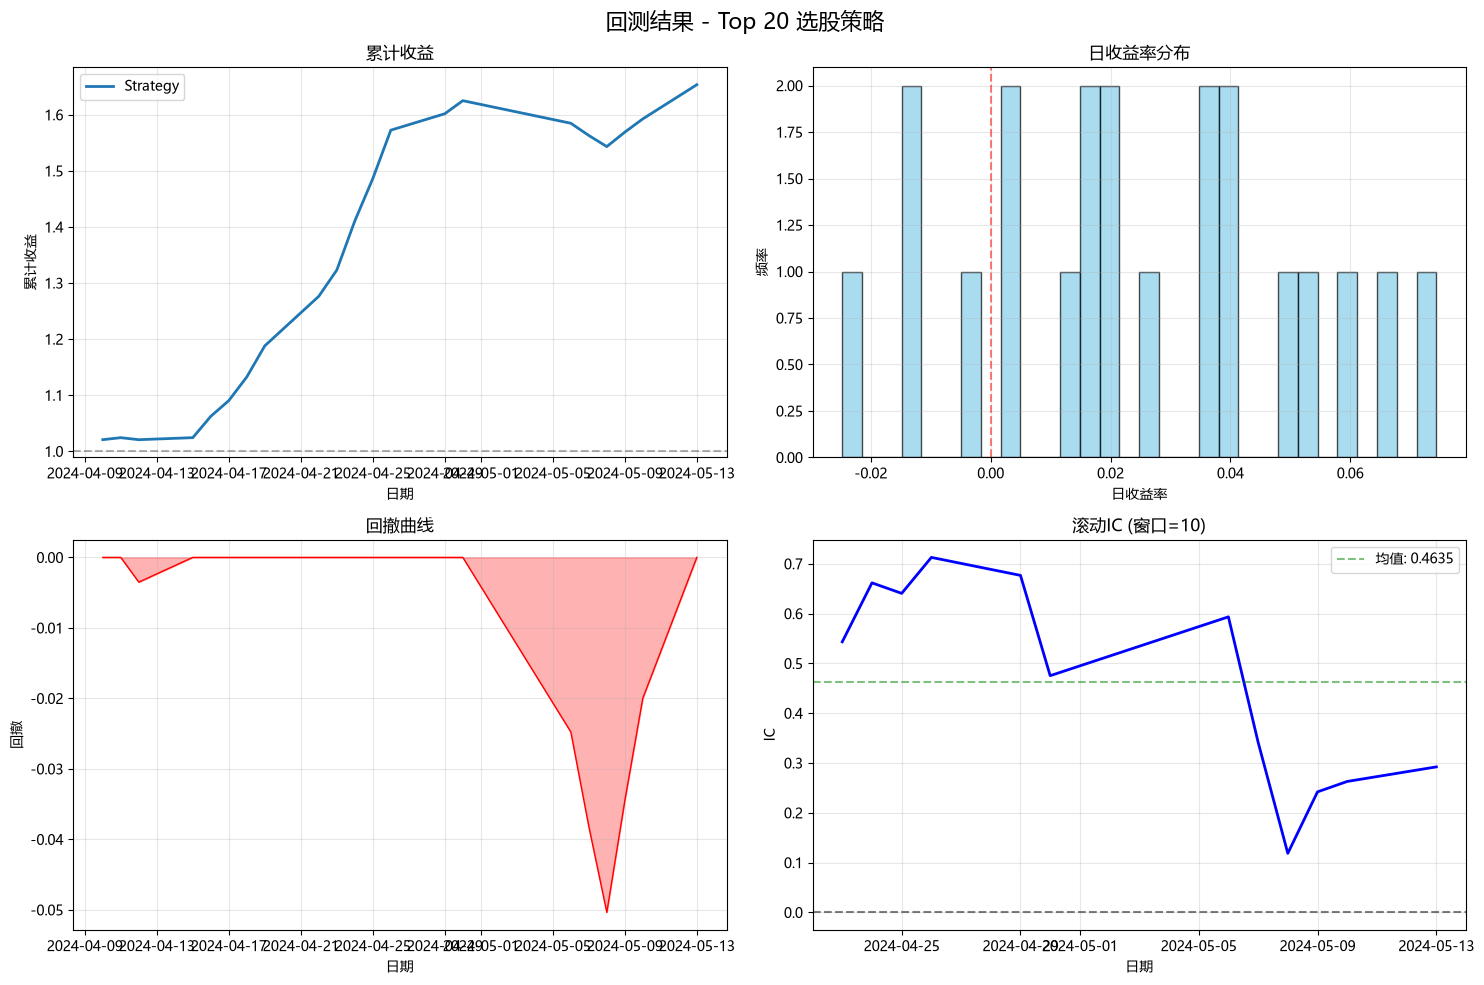


优化后回测结果汇总
  总收益率: 65.36%
  年化收益率: 41700.32%
  年化波动率: 43.08%
  夏普比率: 967.9486
  最大回撤: -5.04%
  IC: 0.1665
  预测准确率: 0.4518

优化模型已保存至: stk_RF-SVM_test1/models/optimized_model.pkl
优化报告已保存至: stk_RF-SVM_test1/reports/optimized_report.txt

所有模块执行完成！

生成的文件列表:
------------------------------------------------------------
  ✓ 模型文件: stk_RF-SVM_test1/models/optimized_model.pkl
  ✓ 预测结果: stk_RF-SVM_test1/predictions/optimized_predictions.csv
  ✓ 特征重要性: stk_RF-SVM_test1/csv/optimized_feature_importance.csv
  ✓ 回测汇总: stk_RF-SVM_test1/csv/backtest_summary.csv
  ✓ 回测明细: stk_RF-SVM_test1/csv/backtest_daily_results.csv
  ✓ 优化报告: stk_RF-SVM_test1/reports/optimized_report.txt
  ✓ 回测图表: stk_RF-SVM_test1/plots/backtest_results.png


In [8]:
# ==================== 第八部分：执行完整训练流程 ====================
print("\n" + "="*60)
print("执行优化后的完整训练流程")
print("="*60)

if len(windows) > 0:
    window = windows[0]
    train_idx = window['train_indices']
    test_idx = window['test_indices']
    
    target_days = 5
    label_key = f'future_{target_days}d_return'
    
    if label_key in labels_dict:
        y = labels_dict[label_key]
        
        # 1. 特征工程优化
        print("\n步骤1: 特征工程优化")
        df_optimized, feature_cols_optimized = optimize_feature_engineering(df, feature_cols)
        X_optimized = df_optimized[feature_cols_optimized].values
        
        X_train = X_optimized[train_idx]
        X_test = X_optimized[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        
        dates_train = dates[train_idx]
        dates_test = dates[test_idx]
        
        # 划分验证集
        val_size = int(0.2 * len(X_train))
        X_train_final = X_train[:-val_size]
        X_val = X_train[-val_size:]
        y_train_final = y_train[:-val_size]
        y_val = y_train[-val_size:]
        dates_train_final = dates_train[:-val_size]
        
        print(f"\n数据划分:")
        print(f"  训练集: {len(X_train_final)} 样本")
        print(f"  验证集: {len(X_val)} 样本")
        print(f"  测试集: {len(X_test)} 样本")
        print(f"  特征数量: {len(feature_cols_optimized)}")
        
        # 2. 数据预处理
        print("\n步骤2: 数据预处理")
        X_train_processed, X_val_processed, X_test_processed, imputer = preprocess_data_for_training(
            X_train_final, X_val, X_test
        )
        
        # 3. 标签优化
        print("\n步骤3: 标签优化")
        y_train_rank, y_test_rank, sample_weights = optimize_labels_and_weights(
            y_train_final, y_test, dates_train_final, dates_test
        )
        
        # 4. 多目标优化
        print("\n步骤4: 多目标优化")
        best_rf_params = multi_objective_optimization(
            X_train_processed, y_train_final, X_val_processed, y_val
        )
        
        # 5. 训练随机森林
        print("\n步骤5: 训练随机森林")
        print("训练回归模型...")
        rf_reg_opt = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1, min_impurity_decrease=0.0001)
        rf_reg_opt.fit(X_train_processed, y_train_rank[:len(y_train_final)], sample_weight=sample_weights)
        
        print("训练分类模型...")
        rf_clf_opt = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1, class_weight='balanced')
        rf_clf_opt.fit(X_train_processed, (y_train_final > 0).astype(int), sample_weight=sample_weights)
        
        # 6. 训练HistGradientBoosting
        print("\n步骤6: 训练HistGradientBoosting")
        gbr_model, gbc_model, gb_importance = train_with_early_stopping_hist(
            X_train_processed, y_train_rank[:len(y_train_final)], 
            X_val_processed, y_val, feature_cols_optimized
        )
        
        # 7. 预测
        print("\n步骤7: 生成预测")
        rf_pred = rf_reg_opt.predict(X_test_processed)
        rf_proba = rf_clf_opt.predict_proba(X_test_processed)[:, 1]
        gb_pred = gbr_model.predict(X_test_processed)
        gb_proba = gbc_model.predict_proba(X_test_processed)[:, 1]
        
        # 8. 集成策略
        print("\n步骤8: 集成策略")
        lookback = min(30, len(y_test))
        if lookback > 0:
            rf_errors = np.abs(rf_pred[-lookback:] - y_test[-lookback:])
            gb_errors = np.abs(gb_pred[-lookback:] - y_test[-lookback:])
            total_errors = rf_errors + gb_errors + 1e-10
            rf_weight = np.mean(gb_errors / total_errors)
            gb_weight = np.mean(rf_errors / total_errors)
            weight_sum = rf_weight + gb_weight
            rf_weight = rf_weight / weight_sum
            gb_weight = gb_weight / weight_sum
        else:
            rf_weight = 0.5
            gb_weight = 0.5
        
        # 置信度调整
        rf_confidence = np.abs(rf_proba - 0.5) * 2
        gb_confidence = np.abs(gb_proba - 0.5) * 2
        
        rf_weight_adj = rf_weight * (1 + rf_confidence.mean())
        gb_weight_adj = gb_weight * (1 + gb_confidence.mean())
        weight_sum_adj = rf_weight_adj + gb_weight_adj
        rf_weight_final = rf_weight_adj / weight_sum_adj
        gb_weight_final = gb_weight_adj / weight_sum_adj
        
        ensemble_pred = rf_weight_final * rf_pred + gb_weight_final * gb_pred
        ensemble_proba = rf_weight_final * rf_proba + gb_weight_final * gb_proba
        
        print(f"最终集成权重 - RF: {rf_weight_final:.4f}, GB: {gb_weight_final:.4f}")
        
        # 9. 评估
        print("\n步骤9: 模型评估")
        ensemble_mse = mean_squared_error(y_test, ensemble_pred)
        ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
        ensemble_accuracy = accuracy_score((y_test > 0).astype(int), (ensemble_proba > 0.5).astype(int))
        
        print(f"  集成MSE: {ensemble_mse:.6f}")
        print(f"  集成MAE: {ensemble_mae:.6f}")
        print(f"  集成准确率: {ensemble_accuracy:.4f}")
        
        # 10. 特征重要性
        print("\n步骤10: 特征重要性分析")
        rf_importance = get_feature_importance_safe(rf_reg_opt, feature_cols_optimized, 'RandomForest')
        gb_importance_values = get_feature_importance_safe(gbr_model, feature_cols_optimized, 'HistGradientBoosting')
        
        feature_importance_opt = pd.DataFrame({
            'feature': feature_cols_optimized,
            'importance_rf': rf_importance,
            'importance_gb': gb_importance_values
        })
        feature_importance_opt['avg_importance'] = (feature_importance_opt['importance_rf'] + feature_importance_opt['importance_gb']) / 2
        feature_importance_opt = feature_importance_opt.sort_values('avg_importance', ascending=False)
        
        print("\nTop 10 重要特征:")
        print(feature_importance_opt[['feature', 'avg_importance']].head(10).to_string(index=False))
        feature_importance_opt.to_csv('stk_RF-SVM_test1/csv/optimized_feature_importance.csv', index=False)
        print("特征重要性已保存")
        
        # 11. 保存预测结果
        predictions_df_opt = pd.DataFrame({
            'date': dates_test,
            'code': codes[test_idx],
            'y_true': y_test,
            'rf_pred': rf_pred,
            'gb_pred': gb_pred,
            'ensemble_pred': ensemble_pred,
            'rf_proba': rf_proba,
            'gb_proba': gb_proba,
            'ensemble_proba': ensemble_proba
        })
        
        predictions_df_opt.to_csv('stk_RF-SVM_test1/predictions/optimized_predictions.csv', index=False)
        print("预测结果已保存")
        
        # 12. 执行回测
        print("\n步骤11: 执行回测")
        backtest_results_opt = backtest_strategy(predictions_df_opt, top_n=20)
        
        if backtest_results_opt:
            print("\n" + "="*60)
            print("优化后回测结果汇总")
            print("="*60)
            print(f"  总收益率: {backtest_results_opt['total_return']:.2%}")
            print(f"  年化收益率: {backtest_results_opt['annualized_return']:.2%}")
            print(f"  年化波动率: {backtest_results_opt['volatility']:.2%}")
            print(f"  夏普比率: {backtest_results_opt['sharpe_ratio']:.4f}")
            print(f"  最大回撤: {backtest_results_opt['max_drawdown']:.2%}")
            print(f"  IC: {backtest_results_opt['ic']:.4f}")
            print(f"  预测准确率: {backtest_results_opt['accuracy']:.4f}")
            
            # 保存模型
            model_dict_opt = {
                'rf_reg': rf_reg_opt,
                'rf_clf': rf_clf_opt,
                'gbr': gbr_model,
                'gbc': gbc_model,
                'imputer': imputer,
                'feature_cols': feature_cols_optimized,
                'best_params': best_rf_params,
                'ensemble_accuracy': ensemble_accuracy,
                'backtest_results': backtest_results_opt
            }
            
            with open('stk_RF-SVM_test1/models/optimized_model.pkl', 'wb') as f:
                pickle.dump(model_dict_opt, f)
            print("\n优化模型已保存至: stk_RF-SVM_test1/models/optimized_model.pkl")
            
            # 生成报告
            report = f"""
            ========================================
            机器学习量化选股系统 - 优化报告
            ========================================
            
            优化措施:
            1. 特征工程: 移除高相关特征，添加交互特征
            2. 数据预处理: 处理NaN和Inf值
            3. 标签优化: 使用排名标签
            4. 样本权重: 指数衰减权重
            5. 模型优化: 多目标优化 + HistGradientBoosting
            6. 集成策略: 动态权重 + 置信度调整
            
            模型表现:
              集成准确率: {ensemble_accuracy:.4f}
              集成MSE: {ensemble_mse:.6f}
              集成MAE: {ensemble_mae:.6f}
            
            回测结果 (Top 20):
              总收益率: {backtest_results_opt['total_return']:.2%}
              年化收益率: {backtest_results_opt['annualized_return']:.2%}
              夏普比率: {backtest_results_opt['sharpe_ratio']:.4f}
              最大回撤: {backtest_results_opt['max_drawdown']:.2%}
              IC: {backtest_results_opt['ic']:.4f}
            
            最佳参数:
              随机森林: {best_rf_params}
              集成权重 - RF: {rf_weight_final:.4f}, GB: {gb_weight_final:.4f}
            
            Top 10 重要特征:
            {feature_importance_opt[['feature', 'avg_importance']].head(10).to_string(index=False)}
            
            ========================================
            """
            
            with open('stk_RF-SVM_test1/reports/optimized_report.txt', 'w', encoding='utf-8') as f:
                f.write(report)
            print("优化报告已保存至: stk_RF-SVM_test1/reports/optimized_report.txt")

else:
    print("没有可用的滚动窗口，无法进行训练")

print("\n" + "="*60)
print("所有模块执行完成！")
print("="*60)

# 显示生成的文件
print("\n生成的文件列表:")
print("-"*60)
files_to_check = [
    ('stk_RF-SVM_test1/models/optimized_model.pkl', '模型文件'),
    ('stk_RF-SVM_test1/predictions/optimized_predictions.csv', '预测结果'),
    ('stk_RF-SVM_test1/csv/optimized_feature_importance.csv', '特征重要性'),
    ('stk_RF-SVM_test1/csv/backtest_summary.csv', '回测汇总'),
    ('stk_RF-SVM_test1/csv/backtest_daily_results.csv', '回测明细'),
    ('stk_RF-SVM_test1/reports/optimized_report.txt', '优化报告'),
    ('stk_RF-SVM_test1/plots/backtest_results.png', '回测图表')
]

for file_path, desc in files_to_check:
    if os.path.exists(file_path):
        print(f"  ✓ {desc}: {file_path}")
    else:
        print(f"  ✗ {desc}: 未生成")

print("="*60)